# Proyecto Final
## Clasificación automática y descubrimiento de subtemas en quejas de consumidores financieros

Dataset: CFPB Consumer Complaint Database (2011–2019)

Alumnos:
- Carlos Flores Varas - 0250946
- Mauro Rogelio Galindo Ibarra - 0250061


## Dataset

- Fuente: CFPB Consumer Complaint Database, (<https://www.kaggle.com/datasets/selener/consumer-complaint-database>). 
  - Consumer Financial Protection Bureau (CFPB), es una agencia del gobierno de Estados Unidos encargada de la protección
    del consumidor en asuntos financieros, regulando asuntos con bancos, uniones de crédito, prestamistas, y  otros.
- Objetivo: clasificación de quejas y detección de subtemas emergentes.
  - Solución: ML Supervisado + NLP + ML No supervisado


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import geopandas as gpd

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score, silhouette_score,
)
from sklearn.model_selection import train_test_split

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

DATA_PATH = 'https://www.kaggle.com/api/v1/datasets/download/selener/consumer-complaint-database'
ESTADOS_EUA_MAPA_URL = 'https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json'

## Análisis de datos y metadatos

In [25]:
# carga inicial del dataset
df = pd.read_csv(DATA_PATH, low_memory=False, compression='zip')
df.head(5)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,05/10/2019,Checking or savings account,Checking account,Managing an account,Problem using a debit or ATM card,NaN,NaN,NAVY FEDERAL CREDIT UNION,FL,328XX,Older American,NaN,Web,05/10/2019,In progress,Yes,NaN,3238275
1,05/10/2019,Checking or savings account,Other banking product or service,Managing an account,Deposits and withdrawals,NaN,NaN,BOEING EMPLOYEES CREDIT UNION,WA,98204,NaN,NaN,Referral,05/10/2019,Closed with explanation,Yes,NaN,3238228
2,05/10/2019,Debt collection,Payday loan debt,Communication tactics,Frequent or repeated calls,NaN,NaN,CURO Intermediate Holdings,TX,751XX,NaN,NaN,Web,05/10/2019,Closed with explanation,Yes,NaN,3237964
3,05/10/2019,"Credit reporting, credit repair services, or other personal consumer reports",Credit reporting,Incorrect information on your report,Old information reappears or never goes away,NaN,NaN,Ad Astra Recovery Services Inc,LA,708XX,NaN,NaN,Web,05/10/2019,Closed with explanation,Yes,NaN,3238479
4,05/10/2019,Checking or savings account,Checking account,Managing an account,Banking errors,NaN,NaN,ALLY FINANCIAL INC.,AZ,85205,NaN,NaN,Postal mail,05/10/2019,In progress,Yes,NaN,3238460


In [26]:
# hacemos una breve exploración de los datos al azar, tal cual los recibimos en la columna, para visualizar mas ejemplos
df.sample(25, random_state=42)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
1137116,08/30/2013,Bank account or service,Checking account,Deposits and withdrawals,NaN,NaN,NaN,WELLS FARGO & COMPANY,MI,39206,"Older American, Servicemember",NaN,Phone,09/17/2013,Closed with explanation,Yes,No,511036
299823,02/26/2018,"Credit reporting, credit repair services, or other personal consumer reports",Credit reporting,Improper use of your report,Reporting company used your report improperly,"All three major credit bureaus ' have illegally hoarded consumers personal information without this Consumers expressed written consent. Pursuant to the 1974 Privacy Act, all 3 credit bureaus ' violated all privacy rights and allowed personal information to be leaked, due to their false and misleading ways. According to the Fair Debt Collection Practices Act, all three credit bureaus ' maliciously and collectively shared this Consumers personal information to make trillions of dollars, by s...",NaN,"EQUIFAX, INC.",PA,171XX,NaN,Consent provided,Web,02/26/2018,Closed with explanation,Yes,NaN,2826358
313574,02/08/2018,Credit card or prepaid card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Card was charged for something you did not purchase with the card,"Subject: RE: Credit Card Charge Disputed for XXXX Order XXXXGreetings,After examining the merchant and the amount on my credit card statement provided by Chase, I disputed a charge in the amount of $XXXX posted on XX/XX/2017 because neither I, nor anyone authorized, ordered, or signed for the merchandise. In addition, neither I nor anyone authorized received the merchandise represented by this transaction. I have been victimized and asked Chase to reissue a credit in the amount of $XXXX so w...",NaN,JPMORGAN CHASE & CO.,MI,NaN,Servicemember,Consent provided,Web,02/08/2018,Closed with explanation,Yes,NaN,2808397
150567,09/22/2018,Credit card or prepaid card,Store credit card,Fees or interest,Problem with fees,"XXXX credit card stop sending me monthly statements about my credit card more than a year ago and they started to charge me late fees of {$35.00} each month even though I was making monthly payment. \nwhen i opened the credit card with XXXX, I requested to receive the monthly paper statements only via postal mail. \nXXXX intentionally decided not to send me monthly paper statements so I will not know the due date and they can charge me late fees each month. \nXXXX knowingly engage in fraud b...",Company has responded to the consumer and the CFPB and chooses not to provide a public response,SYNCHRONY FINANCIAL,MD,208XX,NaN,Consent provided,Web,09/22/2018,Closed with monetary relief,Yes,NaN,3026675
158805,09/10/2018,Mortgage,Conventional home mortgage,Trouble during payment process,NaN,NaN,Company believes it acted appropriately as authorized by contract or law,Ditech Financial LLC,VA,23139,NaN,Consent not provided,Web,09/11/2018,Closed with explanation,Yes,NaN,3015506
1103832,12/16/2013,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,NaN,OCWEN LOAN SERVICING LLC,GA,30022,NaN,NaN,Postal mail,12/19/2013,Closed with explanation,Yes,No,635861
65340,02/04/2019,"Credit reporting, credit repair services, or other personal consumer reports",Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Experian Information Solutions Inc.,FL,338XX,NaN,Other,Web,02/04/2019,Closed with non-monetary relief,Yes,NaN,3142269
948739,12/23/2014,Debt collection,Federal student loan,Improper contact or sharing of info,Contacted employer after asked not to,NaN,NaN,"National Enterprise Systems, Inc.",FL,335XX,NaN,NaN,Web,12/23/2014,

Con este vistazo, nos podemos dar cuenta que hay algunas columnas con datos muy especificos que han 
sido anonimizados con 'X', por ejemplo, fechas y numeros de telefono, asi como terminaciones de 
ZIP Codes

In [27]:
# cols originales
df.dtypes

,0
Date received,object
Product,object
Sub-product,object
Issue,object
Sub-issue,object
Consumer complaint narrative,object
Company public response,object
Company,object
State,object
ZIP code,object


In [28]:
DATA_DICT = {
    'Date received': 'Fecha en que el CFPB recibió la queja.',
    'Product': 'Categoría principal del producto o servicio financiero.',
    'Sub-product': 'Subcategoría del producto.',
    'Issue': 'Problema reportado por el consumidor.',
    'Sub-issue': 'Detalle del problema dentro del Issue.',
    'Consumer complaint narrative': 'Texto libre de la queja (puede estar vacío).',
    'Company public response': 'Respuesta pública de la empresa (puede estar vacía).',
    'Company': 'Institución financiera señalada.',
    'State': 'Estado de EE.UU. del consumidor.',
    'ZIP code': 'Código postal del consumidor.',
}

usecols = list(DATA_DICT.keys())

# removemos columnas que no vayamos a usar (originalmente teníamos 18)
# ¿por qué? nuestro objetivo está en clasificar con NLP las quejas al 
# area que les corresponde, por esto, descartamos columnas que no aportan
# información para este objetivo.

df = df[usecols]

df

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code
0,05/10/2019,Checking or savings account,Checking account,Managing an account,Problem using a debit or ATM card,NaN,NaN,NAVY FEDERAL CREDIT UNION,FL,328XX
1,05/10/2019,Checking or savings account,Other banking product or service,Managing an account,Deposits and withdrawals,NaN,NaN,BOEING EMPLOYEES CREDIT UNION,WA,98204
2,05/10/2019,Debt collection,Payday loan debt,Communication tactics,Frequent or repeated calls,NaN,NaN,CURO Intermediate Holdings,TX,751XX
3,05/10/2019,"Credit reporting, credit repair services, or other personal consumer reports",Credit reporting,Incorrect information on your report,Old information reappears or never goes away,NaN,NaN,Ad Astra Recovery Services Inc,LA,708XX
4,05/10/2019,Checking or savings account,Checking account,Managing an account,Banking errors,NaN,NaN,ALLY FINANCIAL INC.,AZ,85205
...,...,...,...,...,...,...,...,...,...,...
1282350,12/01/2011,Credit card,NaN,Credit determination,NaN,NaN,NaN,"CITIBANK, N.A.",MO,63301
1282351,12/01/2011,Mortgage,Conventional fixed mortgage,"Loan modification,collection,foreclosure",NaN,NaN,NaN,"BANK OF AMERICA, NATIONAL ASSOCIATION",OH,45248
1282352,12/01/2011,Credit card,NaN,Billing disputes,NaN,NaN,NaN,JPMORGAN CHASE & CO.,OH,43207
1282353,12/01/2011,Mortgage,Conventional adjustable mortgage (ARM),"Loan servicing, payments, escrow account",NaN,NaN,NaN,"BANK OF AMERICA, NATIONAL ASSOCIATION",CO,80920


In [29]:
df['Date received'] = pd.to_datetime(df['Date received'], errors='coerce')

print('Shape:', df.shape)
metadata = pd.DataFrame({
    'columna': df.columns,
    'tipo': df.dtypes.astype(str).values,
    'nulos (%)': (df.isna().mean() * 100).round(2).values,
    'descripcion': [DATA_DICT[c] for c in df.columns],
})
metadata

Shape: (1282355, 10)


,columna,tipo,nulos (%),descripcion
0,Date received,datetime64[ns],0.00,Fecha en que el CFPB recibió la queja.
1,Product,object,0.00,Categoría principal del producto o servicio financiero.
2,Sub-product,object,18.34,Subcategoría del producto.
3,Issue,object,0.00,Problema reportado por el consumidor.
4,Sub-issue,object,41.42,Detalle del problema dentro del Issue.
5,Consumer complaint narrative,object,70.09,Texto libre de la queja (puede estar vacío).
6,Company public response,object,64.98,Respuesta pública de la empresa (puede estar vacía).
7,Company,object,0.00,Institución financiera señalada.
8,State,object,1.51,Estado de EE.UU. del consumidor.
9,ZIP code,object,8.99,Código postal del consumidor.


Duplicados: 27070
Rango de fechas: 2011-12-01 00:00:00 → 2019-05-10 00:00:00
Narrativas no nulas: 383564 (29.9%)


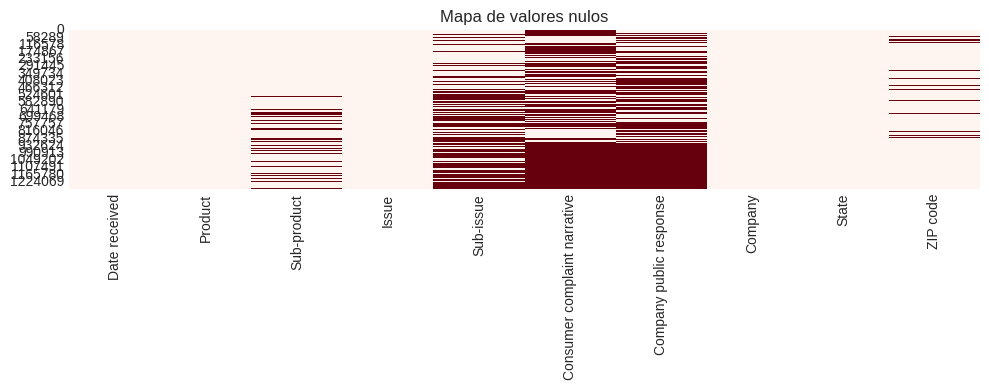

In [30]:
# hacemos una breve exploración de los datos, para visualizar a qué corresponden los valores 
# nulos, duplicados, rango de fechas

print('Duplicados:', df.duplicated().sum())
print('Rango de fechas:', df['Date received'].min(), '→', df['Date received'].max())
print('Narrativas no nulas:', df['Consumer complaint narrative'].notna().sum(),
      f"({df['Consumer complaint narrative'].notna().mean()*100:.1f}%)")

plt.figure(figsize=(10, 4))
sns.heatmap(df.isna(), cbar=False, cmap='Reds')
plt.title('Mapa de valores nulos')
plt.tight_layout()
plt.show()



sobre los metadatos: la narrativa y la respuesta pública concentran casi todos los nulos, el resto de las columnas está prácticamente completo. 

También encontramos 27,070 duplicados exactos, que decidimos no eliminar en esta versión: no estamos seguros de si son quejas repetidas de verdad o un artefacto de cómo el CFPB exporta los datos, y preferimos no perder información sin confirmarlo. Queda como algo a revisar si se sigue puliendo el proyecto.

### Preparación y limpieza de datos 

In [31]:
prod_uniq = df.Product.unique()

print(len(prod_uniq), ":", prod_uniq)


18 : ['Checking or savings account' 'Debt collection'
 'Credit reporting, credit repair services, or other personal consumer reports'
 'Mortgage' 'Student loan' 'Vehicle loan or lease'
 'Credit card or prepaid card' 'Payday loan, title loan, or personal loan'
 'Money transfer, virtual currency, or money service' 'Credit reporting'
 'Credit card' 'Bank account or service' 'Consumer Loan' 'Prepaid card'
 'Other financial service' 'Payday loan' 'Money transfers'
 'Virtual currency']


Al comparar value_counts() de Product nos dimos cuenta de que varias categorías aparecen "partidas" en dos nombres distintos según el año de la queja, se renombraron estas en algún punto entre 2011 y 2019 asi que uificamos las variantes equivalentes antes de modelar.

In [32]:
# Vemos que hay varias categorías de Product que se repiten, por lo que hay
# que unificar variantes equivalentes

# no unificamos money transfers, porque en virtual currency (ej. criptomonedas) se diferencian
# de transfers de dinero tradicionales
mapeo_product_duplicado = {
    'Credit reporting, credit repair services, or other personal consumer reports': 'Credit reporting',
    'Credit card or prepaid card': 'Credit card',
    'Checking or savings account': 'Bank account or service',
}

print('Product ORIGINAL')
top_products = df['Product'].value_counts()


display(top_products)

df['Product_unified'] = df['Product'].replace(mapeo_product_duplicado)


print('\nProduct UNIFICADO')
display(df['Product_unified'].value_counts())

# ahora tenemos menos categoraias de prod:
print(f'Variantes Product UNIFICADO: {df["Product_unified"].nunique()}')


Product ORIGINAL


,count
Product,
Mortgage,278098
Debt collection,244873
"Credit reporting, credit repair services, or other personal consumer reports",225978
Credit reporting,140432
Credit card,89190
Bank account or service,86206
Student loan,51685
Credit card or prepaid card,47653
Checking or savings account,40641



Product UNIFICADO


,count
Product_unified,
Credit reporting,366410
Mortgage,278098
Debt collection,244873
Credit card,136843
Bank account or service,126847
Student loan,51685
Consumer Loan,31605
Vehicle loan or lease,11377
"Money transfer, virtual currency, or money service",10164


Variantes Product UNIFICADO: 15


Por qué unificamos: Credit reporting estaba repartido en dos etiquetas históricas que en la práctica significan lo mismo. nos pasó algo parecido con Credit card y las cuentas bancarias. Si no corregíamos esto, el clasificador iba a tratar una misma categoría real como si fueran dos clases distintas un error que habría inflado artificialmente la dificultad del problema.

Además, vemos que hay unas cuantas categorías que aglomeran la gran mayoría de resultados. El resto las podemos guardar como 'Otro'


In [33]:
# en unified, manten solo los valores de product de las top 8, el resto, lo agrupamos en "Other"
top_prods = df['Product_unified'].value_counts().head(8).index.tolist()
df['Product_unified'] = df['Product_unified'].where(df['Product_unified'].isin(top_prods), 'Other')
df['Product_unified'].value_counts()


,count
Product_unified,
Credit reporting,366410
Mortgage,278098
Debt collection,244873
Credit card,136843
Bank account or service,126847
Student loan,51685
Other,34617
Consumer Loan,31605
Vehicle loan or lease,11377


In [34]:
# Ahora buscamos limpiar la columna de narrative:
# Como vimos en el muestreo de datos inicial (justo despues de cargar los datos), parece que
# se han anonimizado datos, hay que tomar esto en cuenta para nuestro modelo de NLP, sino podria
# afectar su calidad. Haremos una pequeña visualizacion de estas columnas otra vez.

pd.set_option('display.max_colwidth', 500)
df[df['Consumer complaint narrative'].notna() &
    df['Issue'].notna() &
    df['Sub-issue'].notna()
   ].sample(10, random_state=32)[['Product_unified', 'Consumer complaint narrative', "Issue", "Sub-issue", "ZIP code"]]


,Product_unified,Consumer complaint narrative,Issue,Sub-issue,ZIP code
509535,Debt collection,"Since last XXXX , Commonwealth Financial has b een r eporting several medical debts it claims I owe to the major credit bureaus ( i.e. XXXX ). The amounts are {$57.00}, {$300.00}, and {$590.00}. It says the debts are owed to XXXX XXXX XXXX and/or XXXX XXXX XXXX . I have no record of any debts as it reported, nor have I received any notice of collection fro m Commonwealth themselves. I have disputed the debts a number of times, since finding them on my credit report,...",False statements or representation,Attempted to collect wrong amount,346XX
112494,Credit reporting,Cancelled wireless account XXXX with XXXX well within their early termination period. Account has since gone to collections. Have contacted XXXX as well as collection agency requesting a debt validation letter which both parties refuse to provide.,Incorrect information on your report,Account status incorrect,774XX
392377,Credit reporting,I notified all 3 bureau I was never late They never responded. I contacted XXXX XXXX they said I was never late.,Incorrect information on your report,Account status incorrect,07086
191955,Debt collection,"We had a Discover Card. When my husband 's business went under, it was one of the monthly debts we stopped paying. That debt was purchased by XXXX & XXXX from NJ. The firm got a judgment against us in the amount of $ XXXX. We did owe the money and entered into a monthly payment plan with them. They do not send monthly statements or receipt of payments. We would like to know our balance and get a receipt when a payment is made -- if not monthly -- at least quarterly. \n\nWe had been making pa...",Written notification about debt,Didn't receive enough information to verify debt,080XX
385853,Credit reporting,"I recent disputed inquries on my credit report to XXXX due to some fraudulent activities. Companies such as : XXXX XXXX XXXX XXXX, XXXX XXXX, XXXX XXXX, XXXX XXXX, XXXX XXXX, XXXX XXXX, XXXX XXXX, XXXX XXXX.",Improper use of your report,Credit inquiries on your report that you don't recognize,381XX
183496,Debt collection,"I acquired roughly {$5000.00} of debt in XXXX. Within the last couple of months, now in XXXX, payments are being withheld from my paycheck from XXXX XXXX , XXXX My tax returns from the last 6 years have been withheld amounting roughly {$6000.00} because of this. I just received a bill stating I still owe roughly {$8000.00}.",False statements or representation,Attempted to collect wrong amount,680XX
832651,Debt collection,I signed up with XXXX XXXX XXXX to handle my electric bill. They Canceled my service I do not know why?. I did not cancel it. Now they have XXXX collection agency after me. The first XXXX is XXXX XXXX XXXX XXXX XXXX XXXX. Account # XXXX XXXX # XXXX and the other company is CBCS ( XXXX XXXX XXXX. Account # XXXX And The CBCS account # XXXX. I paid all my bills and I do not know Why they canceled me. I will not pay for something this.,Cont'd attempts collect debt not owed,Debt is not mine,080XX
39384,Debt collection,"I paid a medical debt on my credit directly to XXXX XXXX XXXX. I have informed both XXXX XXXX XXXX of the payment as well as the 3rd party company Eastern Account Systems. I was promised removal of debt from my credit reports XXXX, XXXX and XXXX upon payment. I want the negative remark removed from my credit because its damaging my ability to purchase a home and obtain new credit.",Attempts to collect debt not owed,Debt was paid,78660
575674,Debt collection,I am being repeatedly called by Comenity Bank over a credit card that I am currently paying off. I am being called multiple times a day and they always call from an unknown number and only identify themselves as Comenity Bank after I answer. As of today I have been called 4 times. Once every 2 hours from an unknown number. When they call I sternly say this is harassment and before I can say anything else they hang up. They have gone so fa

In [35]:
# investigamos un poco más

narr = df.loc[df['Consumer complaint narrative'].notna(), 'Consumer complaint narrative']
pct_xxxx = narr.str.contains(r'X{2,}', regex=True, na=False).mean() * 100
print(f'{pct_xxxx:.1f}% de narrativas contienen enmascaramiento XXXX (datos personales redactados)')

ejemplos_xxxx = narr[narr.str.contains('XXXX', na=False)].head(3)
for i, txt in enumerate(ejemplos_xxxx, 1):
    print(f'\nEjemplo {i} \n{txt[:450]}...')

85.0% de narrativas contienen enmascaramiento XXXX (datos personales redactados)

Ejemplo 1 
The Summer of XX/XX/2018 I was denied a mortgage loan due to a charge off from XXXX XXXX credit card. I both mailed an account validation letter and disputed this debt with the credit bureaus and the credit card company several times. Only the credit bureaus responded that this debt was verified but showed no proof as I requested. XXXX XXXX still has not responded to any of my letters since XX/XX/2018. All I asked was that the credit bureaus show...

Ejemplo 2 
There is an account reporting on my credit report from XXXX XXXX which is saying the balance is coming from XXXX XXXX XXXX XXXX from XX/XX/2012. I never signed a joint lease with anyone, I have asked several times for a copy of this lease I supposed I signed. The credit bureau is allowing this allow to report on my credit report when it does not belong to me, Please have this account investigated and removed from my credit report. I cont

Algo que notamos leyendo narrativas de verdad (no solo mirando estadísticas) esque hay redacatados con XXXX, y aparece en el 85% de las narrativas. Si no se trata antes de vectorizar, esos tokens no aportan nada al modelo por eso los reemplazamos por redacted en clean_text en vez de simplemente borrarlos, así al menos el modelo sabe que ahí hubo un dato sensible, aunque no sepa cuál.

In [36]:
# limpiamos el texto de las narrativas, cambiando el patron con X, por "redacted"
# y que quede clara la distincion
def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'\b[x]{2,}\b', ' redacted ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

muestras = df[df['Consumer complaint narrative'].notna()].sample(2, random_state=42)
comparacion = pd.DataFrame({
    'original': muestras['Consumer complaint narrative'].str[:350].values,
    'despues_clean_text': muestras['Consumer complaint narrative'].map(clean_text).str[:350].values,
})
comparacion

,original,despues_clean_text
0,"I bought a XXXX XXXX XXXX with XXXX milies ont it from XXXX XXXX, the car currently has XXXX miles on it and is listed in the XXXX XXXX XXXX for only XXXX, but yet I'm paying {$400.00} a month for 4 years which will total out to be around XXXX after it's all said and done. The car is in terrible condition. I purchased it in XX/XX/2016, and the tr",i bought a redacted redacted redacted with redacted milies ont it from redacted redacted the car currently has redacted miles on it and is listed in the redacted redacted redacted for only redacted but yet i m paying a month for years which will total out to be around redacted after it s all said and done the car is in terrible condition i purchase
1,"What happenedDescribe what happened so we can understand the issue ... \n\nSaturday XXXX XXXX, XXXX and major complaint. Previous complaints addressed harassing phone calls. You stated that no more phone calls. I was awaken at XXXX Hawaii Standard Time by a phone call from your representative. Message from Representative XXXX XXXX, to call her at XXX",what happeneddescribe what happened so we can understand the issue saturday redacted redacted redacted and major complaint previous complaints addressed harassing phone calls you stated that no more phone calls i was awaken at redacted hawaii standard time by a phone call from your representative message from representative redacted redacted to cal


Nos vamos a enfocar en aquellas filas con narrative. ¿Por qué? porque aunque 
para el análisis/agrupación de problemas (más específico, no solo por issue/sub-issue) 
con NLP podríamos prescindir de ello, obtendríamos muy poco valor. La columna de narrativa
tiene un valor muy alto, su problema es que son datos sin estructura.


In [39]:
df['has_narrative'] = df['Consumer complaint narrative'].notna()

In [40]:
# eliminar?
nlp_df = df[df['has_narrative']].copy()
print(f'Filas con narrativa: {len(nlp_df):,} de {len(df):,} ({len(nlp_df)/len(df)*100:.1f}%)')
print('\nDistribución por Product (antes de muestreo):')
print(nlp_df['Product_unified'].value_counts())

SAMPLE_N = 100_000
if len(nlp_df) > SAMPLE_N:
    parts = []
    for _, group in nlp_df.groupby('Product_unified'):
        n = max(500, int(SAMPLE_N * len(group) / len(nlp_df)))
        parts.append(group.sample(min(len(group), n), random_state=42))
    nlp_df = pd.concat(parts).reset_index(drop=True)
    print(f'\nMuestra estratificada para NLP: {len(nlp_df):,} filas')
    print(nlp_df['Product_unified'].value_counts())


Filas con narrativa: 383,564 de 1,282,355 (29.9%)

Distribución por Product (antes de muestreo):
Product_unified
Credit reporting           123966
Debt collection             86710
Mortgage                    52987
Credit card                 40217
Bank account or service     27766
Student loan                21810
Other                       14889
Consumer Loan                9474
Vehicle loan or lease        5745
Name: count, dtype: int64

Muestra estratificada para NLP: 99,995 filas
Product_unified
Credit reporting           32319
Debt collection            22606
Mortgage                   13814
Credit card                10485
Bank account or service     7238
Student loan                5686
Other                       3881
Consumer Loan               2469
Vehicle loan or lease       1497
Name: count, dtype: int64


## Exploratory Data Analysis (EDA)

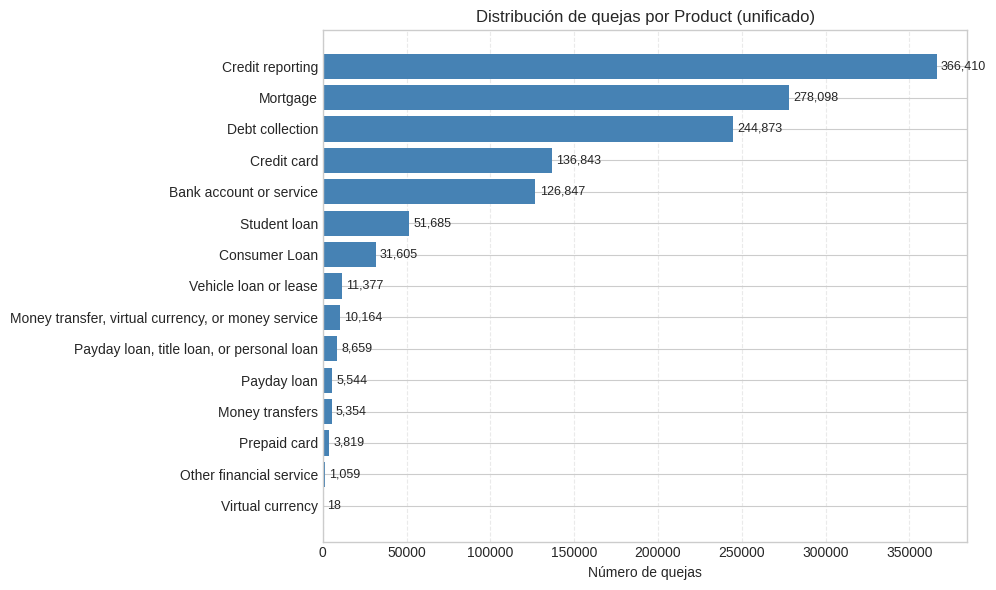

In [ ]:
# exploración inicial, graficando qué productos tienen más quejas
prod = df['Product_unified'].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(prod.index, prod.values, color='steelblue')
ax.set_title('Distribución de quejas por Product')
ax.set_xlabel('Número de quejas')
ax.bar_label(bars, fmt='{:,.0f}', padding=3, fontsize=9)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


La gran mayoría de queas se concentran en 5 categorías: credit reporting, mortgage, debt collection, credit card y bank account or service.

Credit reporting y Mortgage dominan el volumen de quejas por bastnte. Tiene sentido priorizar monitoreo regulatorio ahí, aunque justo por ser tan grandes también son las categorías que más le convienen al modelo.

In [ ]:
# hacemos agrupacion de datos por año y trimestre, para ver si encontramos
# alguna tendencia/patrón con respecto al tiempo

df['has_narrative'] = df['Consumer complaint narrative'].notna()
df['year'] = df['Date received'].dt.year
df['quarter'] = df['Date received'].dt.to_period('Q').astype(str)

df[['Product_unified', 'has_narrative', 'year', 'quarter']].head(3)

,Product_unified,has_narrative,year,quarter
0,Bank account or service,False,2019,2019Q2
1,Bank account or service,False,2019,2019Q2
2,Debt collection,False,2019,2019Q2


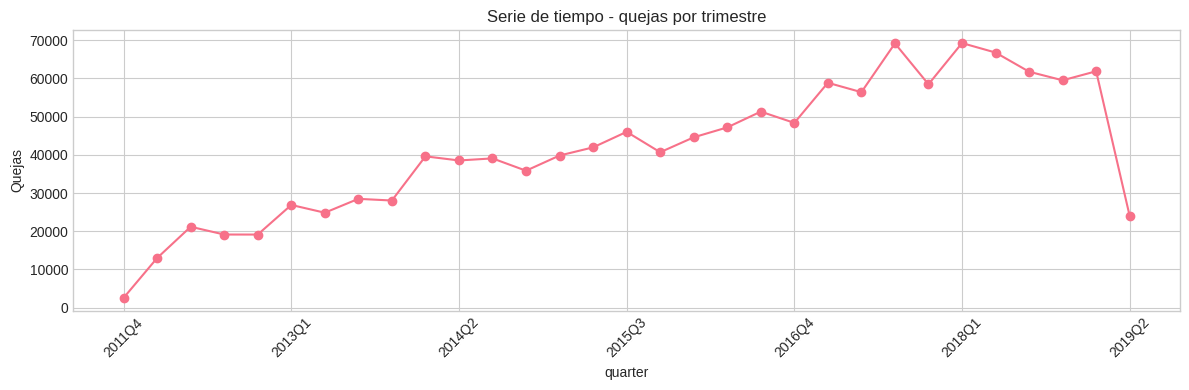

In [ ]:
# hay cambios en la cantidad de quejas por trimestre?
df.groupby('quarter').size().plot(figsize=(12, 4), marker='o')
plt.title('Quejas por trimestre')
plt.ylabel('Quejas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


El volumen crece de forma bastante sostenida hacia 2016–2018. No podemos afirmar con este dataset por qué ¿más digitalización del proceso de queja? ¿más visibilidad? ¿más problemas reales?, pero es consistente con lo que uno esperaría de una plataforma gubernamental vemos una tendencia a que fue ganando adopción con los años.

Conforme pasa el tiempo, vemos que sí aumentan. Este crecimiento parecería concordar con la digitalización
general de los servicios financieros. Sin embargo ese decrecimiento final en 2019Q2 es extraño. Revisemos si 
es porque justo a medio Q2 se da el corte de datos. 


In [ ]:
# el q2 dura de abril (04-01) a junio (06-30)
df.sort_values('Date received', ascending=False).head(3)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Product_unified,has_narrative,year,quarter
0,2019-05-10,Checking or savings account,Checking account,Managing an account,Problem using a debit or ATM card,NaN,NaN,NAVY FEDERAL CREDIT UNION,FL,328XX,Bank account or service,False,2019,2019Q2
9,2019-05-10,"Credit reporting, credit repair services, or other personal consumer reports",Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,CONTRACT CALLERS INC,MD,20774,Credit reporting,False,2019,2019Q2
1,2019-05-10,Checking or savings account,Other banking product or service,Managing an account,Deposits and withdrawals,NaN,NaN,BOEING EMPLOYEES CREDIT UNION,WA,98204,Bank account or service,False,2019,2019Q2


En efecto, los datos se cortan antes de que acabe, por ello la menor cantidad de datos.

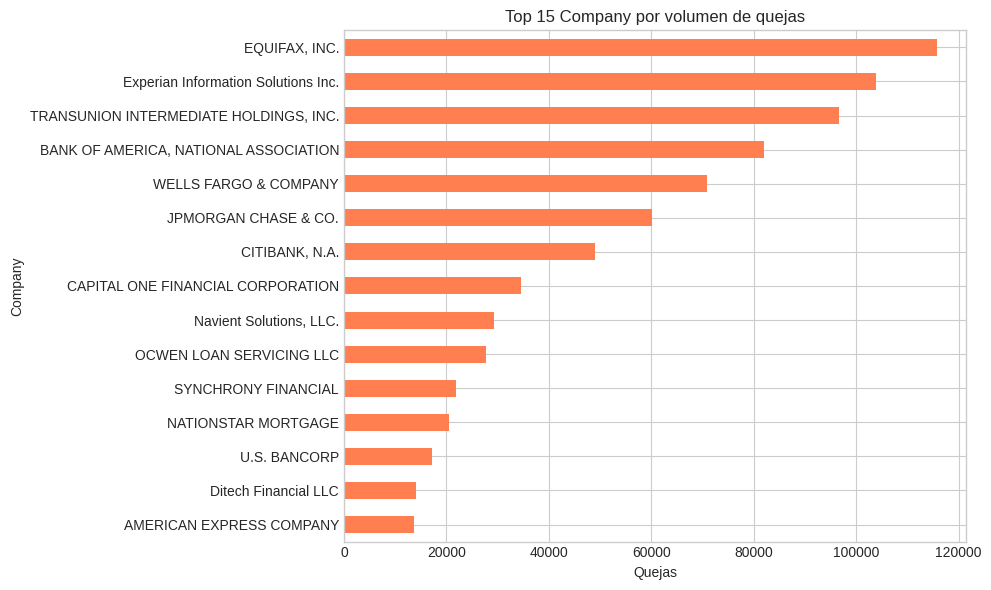

In [ ]:
# ahora exploramos por compañía
top_co = df['Company'].value_counts().head(15)
ax = top_co.plot(kind='barh', figsize=(10, 6), color='coral')
plt.title('Top 15 Company por volumen de quejas')
plt.xlabel('Quejas')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

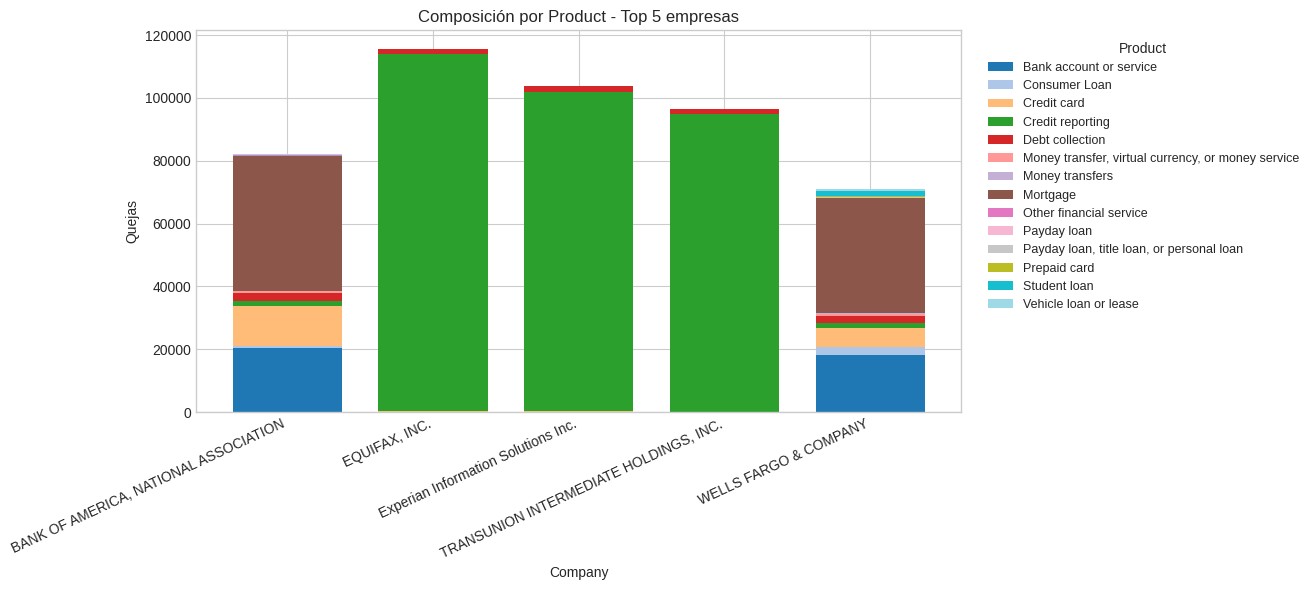

In [ ]:
top5 = df['Company'].value_counts().head(5).index
comp_prod = (
    df[df['Company'].isin(top5)]
    .groupby(['Company', 'Product_unified'])
    .size()
    .unstack(fill_value=0)
)
fig, ax = plt.subplots(figsize=(13, 6))
comp_prod.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', width=0.75)
ax.set_title('Composición por Product - Top 5 empresas')
ax.set_ylabel('Quejas')
ax.set_xlabel('Company')
plt.xticks(rotation=25, ha='right')
ax.legend(title='Product', bbox_to_anchor=(1, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

Las 5 empresas con más quejas no comparten el mismo mix de Product entre sí. Eso confirma que "quién es la empresa" no basta para predecir de qué trata la queja el contenido de la narrativa sí aporta información que la empresa por sí sola no tiene.

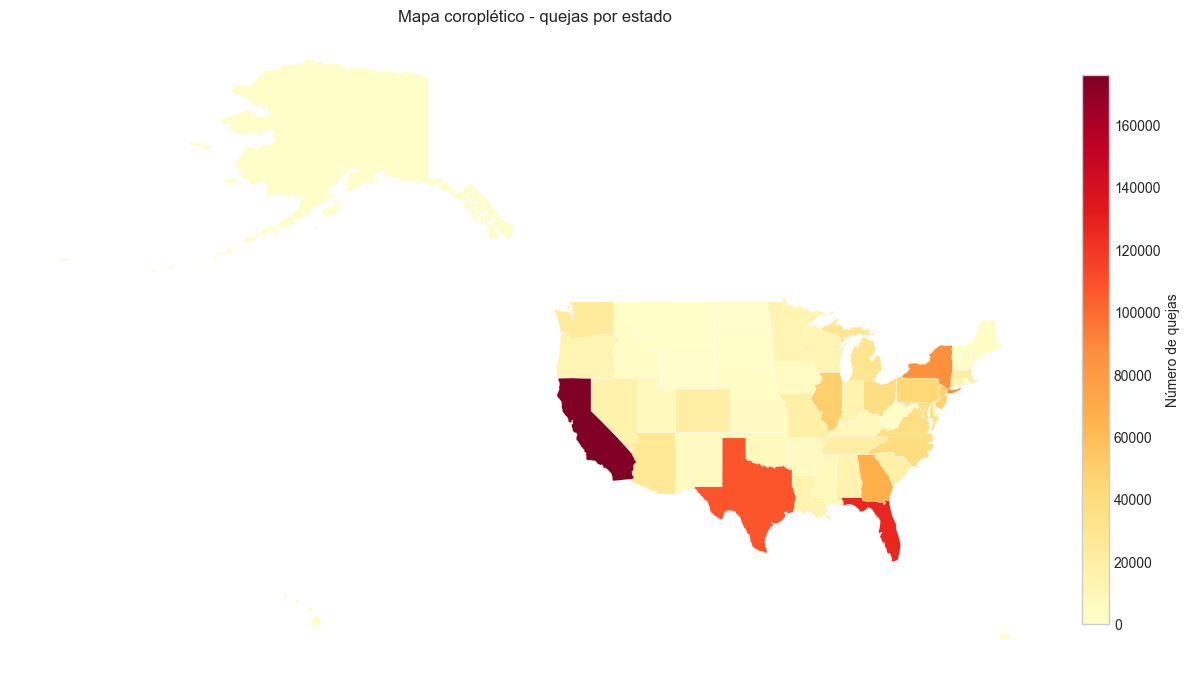

In [ ]:
STATE_ABBR_TO_NAME = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas', 'CA': 'California',
    'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware', 'FL': 'Florida', 'GA': 'Georgia',
    'HI': 'Hawaii', 'ID': 'Idaho', 'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa',
    'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi', 'MO': 'Missouri',
    'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada', 'NH': 'New Hampshire', 'NJ': 'New Jersey',
    'NM': 'New Mexico', 'NY': 'New York', 'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio',
    'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah', 'VT': 'Vermont',
    'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming',
    'DC': 'District of Columbia',
}

states = gpd.read_file(ESTADOS_EUA_MAPA_URL)
state_counts = df.groupby('State').size().reset_index(name='quejas')
state_counts['name'] = state_counts['State'].map(STATE_ABBR_TO_NAME)
merged = states.merge(state_counts, on='name', how='left')
merged['quejas'] = merged['quejas'].fillna(0)

from matplotlib.colors import Normalize
from matplotlib import cm

fig, ax = plt.subplots(figsize=(12, 7))
merged.plot(column='quejas', ax=ax, cmap='YlOrRd', edgecolor='white', linewidth=0.2, legend=False)
norm = Normalize(vmin=merged['quejas'].min(), vmax=merged['quejas'].max())
sm = cm.ScalarMappable(cmap='YlOrRd', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('Número de quejas')
ax.set_title('Mapa coroplético - quejas por estado')
ax.axis('off')
plt.tight_layout()
plt.show()

CA, FL, TX y NY concentran gran parte del volumen, alineado con población y actividad financiera. por lo que seria de esperarse que fuesen los estados con mayor volumen.

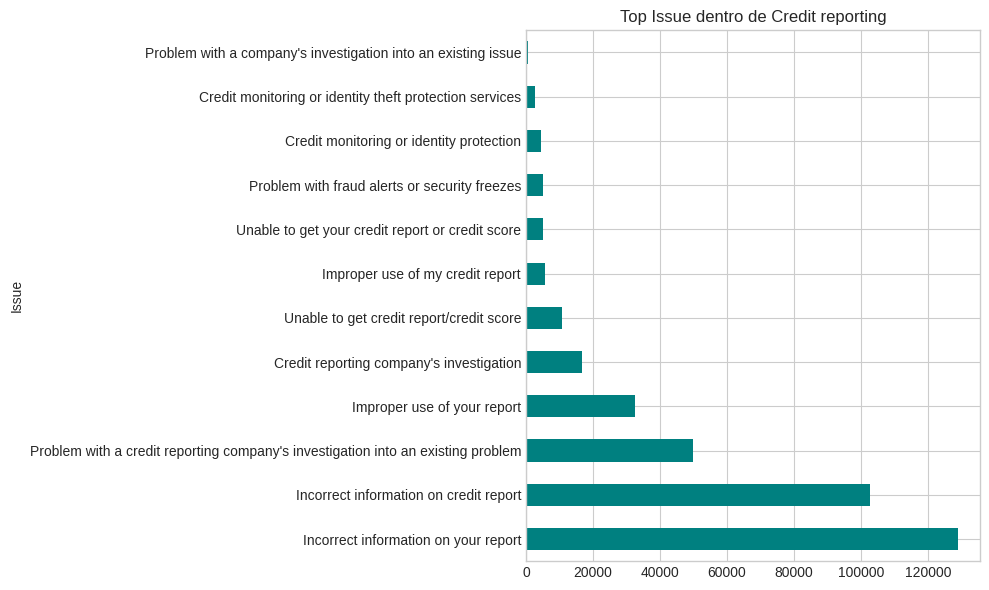

In [ ]:
top_product = df['Product_unified'].value_counts().idxmax()
issue_top = df[df['Product_unified'] == top_product]['Issue'].value_counts().head(12)
issue_top.plot(kind='barh', figsize=(10, 6), color='teal')
plt.title(f'Top Issue dentro de {top_product}')
plt.tight_layout()
plt.show()

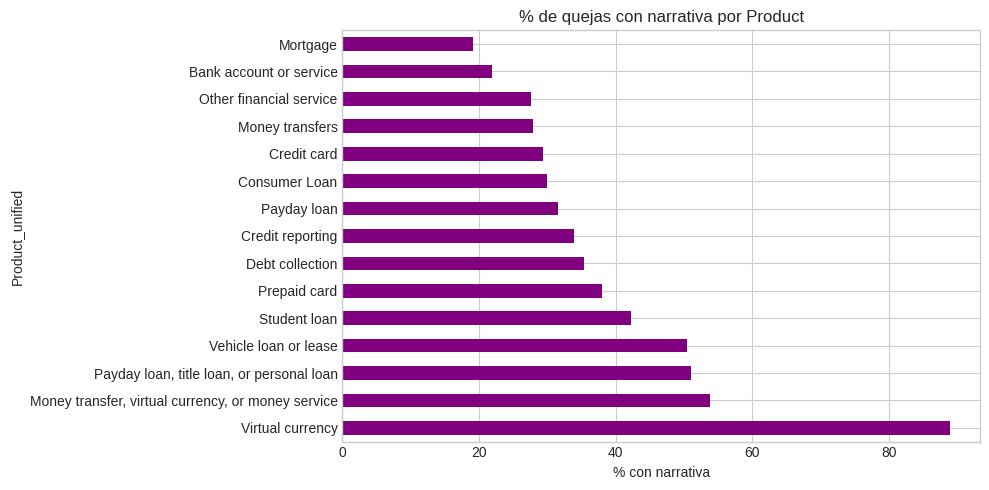

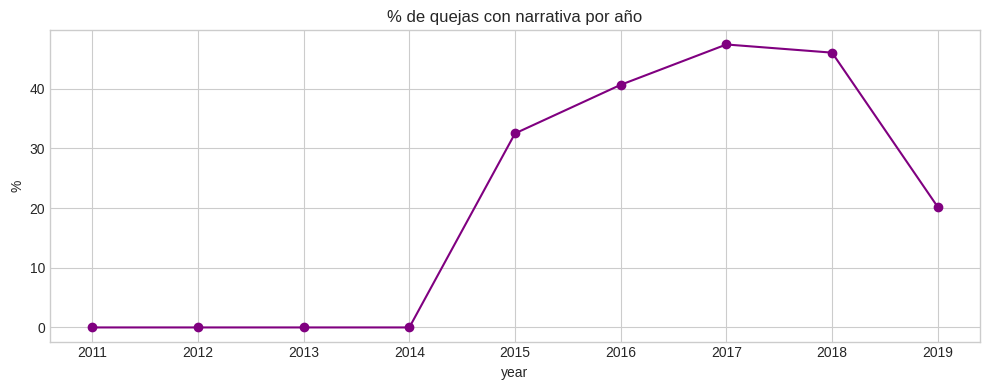

In [ ]:
narr_by_prod = df.groupby('Product_unified')['has_narrative'].mean().sort_values(ascending=False) * 100
narr_by_prod.plot(kind='barh', figsize=(10, 5), color='purple')
plt.title('% de quejas con narrativa por Product')
plt.xlabel('% con narrativa')
plt.tight_layout()
plt.show()

narr_time = df.groupby('year')['has_narrative'].mean() * 100
narr_time.plot(figsize=(10, 4), marker='o', color='purple')
plt.title('% de quejas con narrativa por año')
plt.ylabel('%')
plt.tight_layout()
plt.show()

El porcentaje de quejas con narrativa varía bastante según el Product y sube en los años más recientes. Esto es una buena noticia para la parte de NLP del proyecto: el subconjunto de datos con texto no solo es utilizable hoy, sino que va creciendo con el tiempo.

## Propuesta de negocio

**Problema:** El triage manual de quejas es lento y costoso. Aunque el dataset nos da una categoría inicial con la que trabajar (Product), el problema en concreto (issue)  puede resultar muy general todavía,. Dentro de categorías grandes (p. ej. Credit reporting) pueden existir subproblemas emergentes no capturados a tiempo por una taxonomía fija (Sub-issue). Además de esto, la columna de narrative, tiene detalles mucho más precisos sobre el problema en particular, que al estar en formato de texto libre. 

**Propuesta objetivo (implementada en este proyecto):**
1. Clasificador automático de cada queja nueva a partir del texto libre.
2. Módulo no supervisado de subtemas dentro del producto más grande, como alerta temprana de patrones nuevos.

**Propuesta a futuro (hipotética, desarrollo a futuro):** Este clasificador podría utilizarse ya en sistemas de producción para etiquetar el tipo de problema registrado y así dirigir los problemas a personal de atención al cliente más especializado con mayor rapidez. O en caso de que sean problemas comunes, y resolubles por el cliente, dirigir a instrucciones para resolverlo.

**Posibles beneficiarios/implementadores del sistema propuesto:** reguladores, bancos y aseguradoras, software de atención al cliente financiero.


## Implementación del modelo

### NLP + Supervisado - Clasificación de Product

In [ ]:
nlp_model = nlp_df[nlp_df['Product_unified'] != 'Otros'].copy()
nlp_model['text_clean'] = nlp_model['Consumer complaint narrative'].map(clean_text)
print('Filas para modelado:', len(nlp_model))
nlp_model['Product_unified'].value_counts()

Filas para modelado: 100499


,count
Product_unified,
Credit reporting,32319
Debt collection,22606
Mortgage,13814
Credit card,10485
Bank account or service,7238
Student loan,5686
Consumer Loan,2469
Vehicle loan or lease,1497
"Money transfer, virtual currency, or money service",1425


**Hiperparámetros TF-IDF:** Probamos `max_features` 2000 vs 5000 (con `ngram_range=(1,2)` y `min_df=5` para ignorar términos muy raros).

In [ ]:
X_text = nlp_model['text_clean']
y = nlp_model['Product_unified']

for max_feat in [2000, 5000]:
    vec_tmp = TfidfVectorizer(max_features=max_feat, ngram_range=(1, 2), min_df=5)
    X_tmp = vec_tmp.fit_transform(X_text)
    X_tr, X_te, y_tr, y_te = train_test_split(X_tmp, y, test_size=0.2, random_state=42, stratify=y)
    clf_tmp = LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1)
    clf_tmp.fit(X_tr, y_tr)
    f1 = f1_score(y_te, clf_tmp.predict(X_te), average='macro')
    print(f'max_features={max_feat} → vocabulario={X_tmp.shape[1]:,} | F1 macro={f1:.4f}')

max_features=2000 → vocabulario=2,000 | F1 macro=0.5330
max_features=5000 → vocabulario=5,000 | F1 macro=0.5827


Elegimos max_features=5000 porque captura más n-gramas de productos financieros con una mejora modesta pero estable en F1 macro.

In [ ]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5)
X = tfidf.fit_transform(nlp_model['text_clean'])
y = nlp_model['Product_unified']

idx = np.arange(len(nlp_model))
idx_train, idx_test = train_test_split(
    idx, test_size=0.2, random_state=42, stratify=y
)
X_train, X_test = X[idx_train], X[idx_test]
y_train, y_test = y.iloc[idx_train], y.iloc[idx_test]

log_reg = LogisticRegression(max_iter=2000, class_weight='balanced', n_jobs=-1)
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred)
f1_lr = f1_score(y_test, y_pred, average='macro')
print(f'Logistic Regression - Accuracy: {acc_lr:.4f} | F1 macro: {f1_lr:.4f}')
print(classification_report(y_test, y_pred))

Logistic Regression - Accuracy: 0.7748 | F1 macro: 0.5827
                                                    precision    recall  f1-score   support

                           Bank account or service       0.78      0.80      0.79      1448
                                     Consumer Loan       0.34      0.48      0.40       494
                                       Credit card       0.75      0.74      0.74      2097
                                  Credit reporting       0.90      0.77      0.83      6464
                                   Debt collection       0.83      0.78      0.81      4521
Money transfer, virtual currency, or money service       0.56      0.62      0.59       285
                                   Money transfers       0.31      0.53      0.39       100
                                          Mortgage       0.91      0.90      0.90      2763
                           Other financial service       0.15      0.47      0.23        58
                     

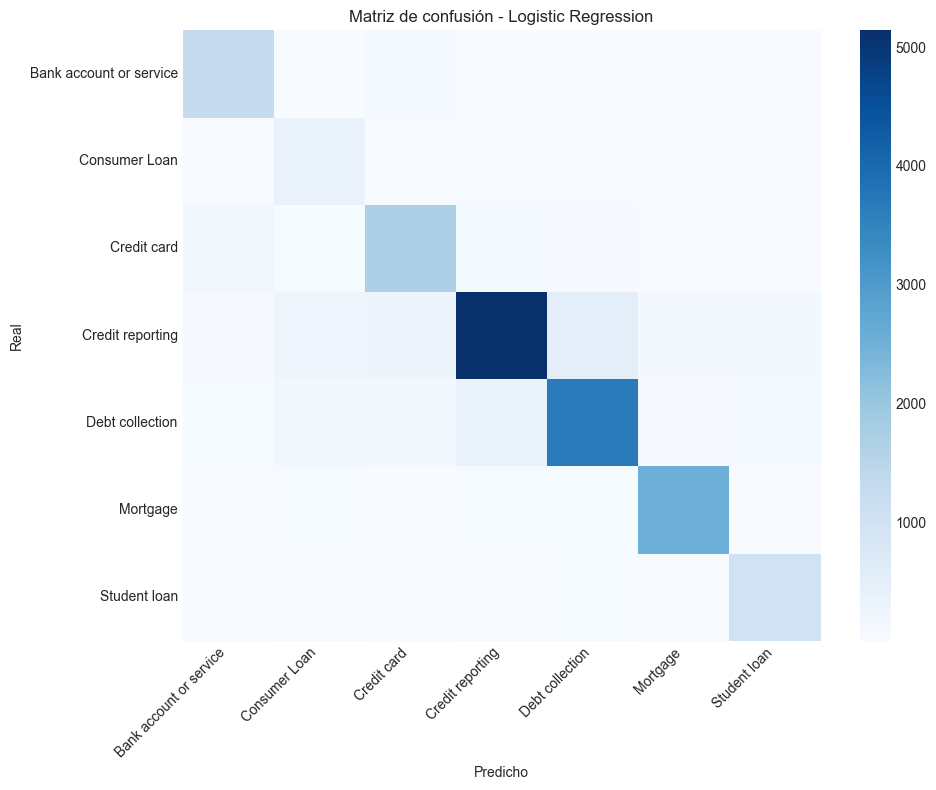

In [167]:
cm = confusion_matrix(y_test, y_pred, labels=log_reg.classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=log_reg.classes_, yticklabels=log_reg.classes_)
plt.title('Matriz de confusión - Logistic Regression')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)
acc_dummy = accuracy_score(y_test, y_pred_dummy)
f1_dummy = f1_score(y_test, y_pred_dummy, average='macro')
print(f'Baseline (clase mayoritaria) - Accuracy: {acc_dummy:.4f} | F1 macro: {f1_dummy:.4f}')
print(f'Logistic Regression - Accuracy: {acc_lr:.4f} | F1 macro: {f1_lr:.4f}')
print(f'Lift vs baseline: +{(acc_lr - acc_dummy)*100:.1f} pp accuracy, +{(f1_lr - f1_dummy)*100:.1f} pp F1 macro')

Baseline (clase mayoritaria) - Accuracy: 0.3216 | F1 macro: 0.0324
Logistic Regression - Accuracy: 0.7748 | F1 macro: 0.5827
Lift vs baseline: +45.3 pp accuracy, +55.0 pp F1 macro


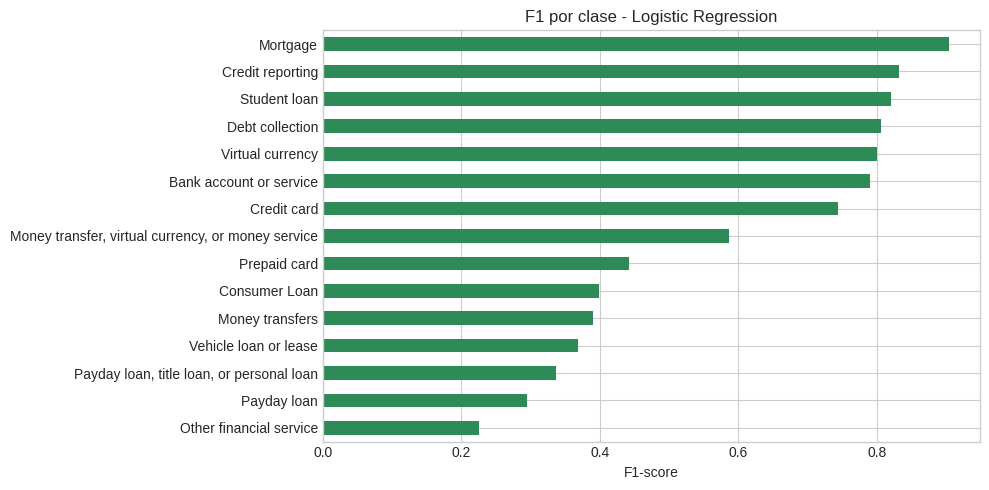

Clases más difíciles: {'Other financial service': 0.225, 'Payday loan': 0.295}
Clases más fáciles: {'Credit reporting': 0.832, 'Mortgage': 0.904}


In [ ]:
report_dict = classification_report(y_test, y_pred, output_dict=True)
f1_por_clase = {k: round(v['f1-score'], 3) for k, v in report_dict.items()
                if k not in ('accuracy', 'macro avg', 'weighted avg')}
f1_series = pd.Series(f1_por_clase).sort_values()
f1_series.plot(kind='barh', figsize=(10, 5), color='seagreen')
plt.title('F1 por clase - Logistic Regression')
plt.xlabel('F1-score')
plt.tight_layout()
plt.show()
print('Clases más difíciles:', f1_series.head(2).to_dict())
print('Clases más fáciles:', f1_series.tail(2).to_dict())

In [ ]:
feature_names = tfidf.get_feature_names_out()
term_rows = []
for idx, label in enumerate(log_reg.classes_):
    coefs = log_reg.coef_[idx]
    top_idx = np.argsort(coefs)[-8:][::-1]
    for rank, ti in enumerate(top_idx, 1):
        term_rows.append({'Product': label, 'rank': rank, 'term': feature_names[ti], 'coef': coefs[ti]})
terms = pd.DataFrame(term_rows)
for product in log_reg.classes_[:3]:
    top = terms[terms['Product'] == product].head(8)
    print(f"\n{product}: {', '.join(top['term'].tolist())}")


Bank account or service: bank, overdraft, deposit, checking, atm, branch, citibank, account

Consumer Loan: vehicle, loan, car, auto, finance, financial, credit, lease

Credit card: card, discover, credit, credit card, citi, chase, capital one, synchrony


In [175]:
from IPython.display import Markdown, display

diff_acc = (acc_lr - acc_dummy) * 100
diff_f1 = (f1_lr - f1_dummy) * 100
hard = f1_series.head(2)
easy = f1_series.tail(2)

print(f"Accuracy del modelo: {acc_lr:.2f}")
print(f"F1 macro del modelo: {f1_lr:.2f}")
print(f"Accuracy del baseline: {acc_dummy:.2f}")
print(f"F1 macro del baseline: {f1_dummy:.2f}")
print(f"Diferencia en accuracy: +{diff_acc:.1f} puntos porcentuales")
print(f"Diferencia en F1 macro: +{diff_f1:.1f} puntos porcentuales")
print(f"Clase más difícil 1: {hard.index[0]} con F1 = {hard.iloc[0]:.2f}")
print(f"Clase más difícil 2: {hard.index[1]} con F1 = {hard.iloc[1]:.2f}")
print(f"Clase más fácil 1: {easy.index[0]} con F1 = {easy.iloc[0]:.2f}")
print(f"Clase más fácil 2: {easy.index[1]} con F1 = {easy.iloc[1]:.2f}")

Accuracy del modelo: 0.83
F1 macro del modelo: 0.79
Accuracy del baseline: 0.34
F1 macro del baseline: 0.07
Diferencia en accuracy: +48.7 puntos porcentuales
Diferencia en F1 macro: +72.0 puntos porcentuales
Clase más difícil 1: Consumer Loan con F1 = 0.52
Clase más difícil 2: Credit card con F1 = 0.78
Clase más fácil 1: Credit reporting con F1 = 0.84
Clase más fácil 2: Mortgage con F1 = 0.91


Ahora vamos a ver qué tan bien funcionó el modelo supervisado. Usamos Logistic Regression y obtuvimos un accuracy de 0.83 y un F1 macro de 0.79 en los datos de prueba. Para saber si esto es bueno o no, lo comparamos contra un modelo base muy simple, que solo predice siempre la categoría más común. Ese modelo base tuvo un accuracy de 0.34 y un F1 macro de 0.07.

La diferencia entre los dos modelos es grande. El modelo real mejora al modelo base en 48.7 puntos porcentuales de accuracy y en 72.0 puntos porcentuales de F1 macro. Esto nos dice algo importante, el texto de la queja sí tiene información útil para predecir la categoría, y no es solo casualidad o el resultado de predecir siempre la clase más frecuente.

Si miramos las categorías por separado, las que más le cuestan al modelo son Consumer Loan, con un F1 de 0.52, y Credit card, con un F1 de 0.78. Por otro lado, las categorías donde el modelo funciona mejor son Credit reporting, con un F1 de 0.84, y Mortgage, con un F1 de 0.91. Esto tiene sentido porque esas categorías suelen tener más ejemplos para entrenar, así que el modelo aprende mejor su vocabulario.

Por último, revisamos las palabras que más influyen en cada categoría según el modelo, y encontramos que son palabras que cualquier persona podría entender con facilidad, por ejemplo palabras relacionadas con hipotecas en la categoría de Mortgage. Esto es una buena señal porque significa que un equipo de cumplimiento normativo podría revisar estas palabras y confirmar que el modelo está aprendiendo cosas razonables, y no solo memorizando patrones raros que no tienen sentido.

In [ ]:
errors_df = pd.DataFrame({
    'texto': nlp_model.iloc[idx_test]['Consumer complaint narrative'].values,
    'real': y_test.values,
    'predicho': y_pred,
})
confundidos = errors_df[errors_df['real'] != errors_df['predicho']]
print(f'Errores en test: {len(confundidos):,} de {len(errors_df):,} ({len(confundidos)/len(errors_df)*100:.1f}%)')

for i, row in confundidos.sample(min(3, len(confundidos)), random_state=42).iterrows():
    print(f"\nReal: {row['real']} | Predicho: {row['predicho']}")
    print(row['texto'][:450])
    print('-' * 70)

Errores en test: 4,527 de 20,100 (22.5%)

Real: Credit reporting | Predicho: Debt collection
Despite numerous attempts to resolve the issue with these extortionists they refuse to provide me with adequate proof required under law that the debt actually belongs to me. First and foremost at the time of the alleged debt I was fully insured by XXXX XXXX and had no debt owed to any hospital as far as I know. I have asked memories times for Proof since my wallet had been taken that year, a report made with the police and was fully employed and
----------------------------------------------------------------------

Real: Bank account or service | Predicho: Money transfer, virtual currency, or money service
This response is with regard to Complaint # XXXX My name is XXXX XXXX. I had thru XX/XX/2018 to provide a feedback to Compass Banks response. Unfortunately I messed it up and sent a feedback that was completely blank. I am sending this feedback via the attached file. I hope it is accepted a

**Error analysis:** Los casos mal clasificados suelen compartir vocabulario entre productos (p. ej. *loan* aparece en *Mortgage* y *Consumer Loan*). ¿Se arregla con más datos o con features adicionales (Sub-product, longitud del texto)? No lo resolvimos aquí - queda como línea de trabajo.

### No supervisado - Sub-temas en Credit reporting

In [ ]:
CLUSTER_PRODUCT = 'Credit reporting'
credit = df[(df['Product_unified'] == CLUSTER_PRODUCT) & df['has_narrative']].copy()
if len(credit) > 25000:
    credit = credit.sample(25000, random_state=42)
credit['text_clean'] = credit['Consumer complaint narrative'].map(clean_text)
print('Muestra clustering:', len(credit))

Muestra clustering: 25000


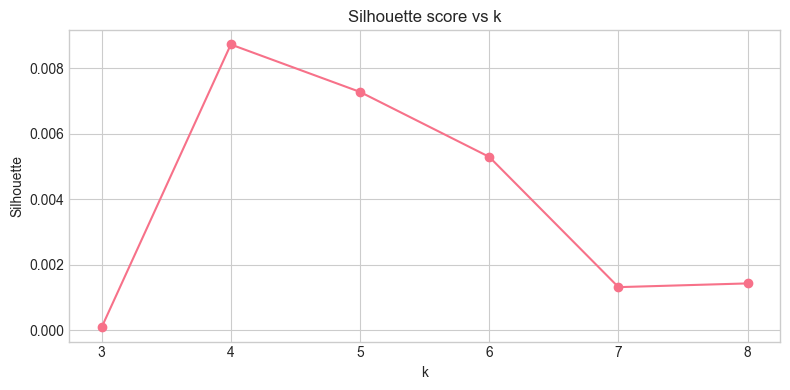

Mejor k: 4 | silhouette: 0.0087


In [168]:
tfidf_cl = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=5)
X_cl = tfidf_cl.fit_transform(credit['text_clean'])

scores = []
K_range = range(3, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cl)
    scores.append(silhouette_score(X_cl, labels))

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), scores, marker='o')
plt.title('Silhouette score vs k')
plt.xlabel('k')
plt.ylabel('Silhouette')
plt.tight_layout()
plt.show()

best_k = list(K_range)[int(np.argmax(scores))]
print('Mejor k:', best_k, '| silhouette:', round(max(scores), 4))

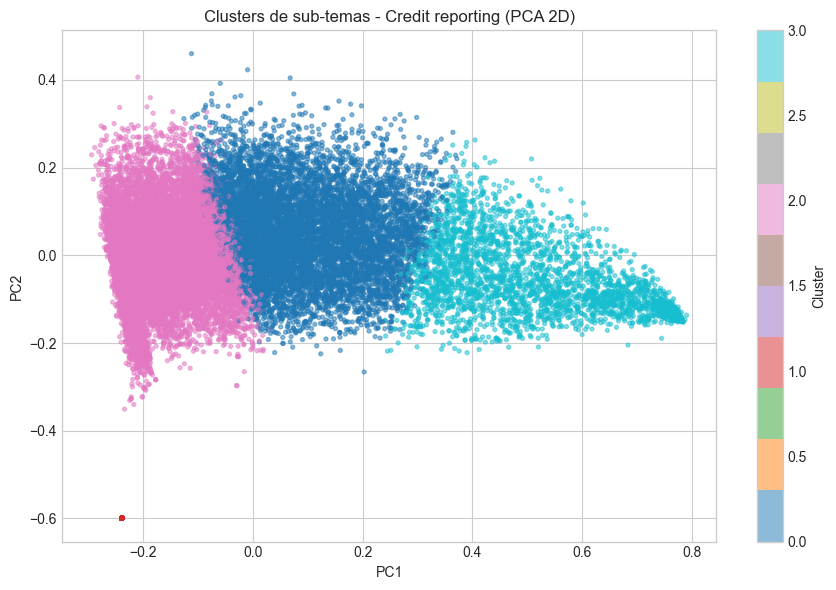

Cluster 0 - redacted, redacted redacted, the, to, and
Cluster 1 - mistakes appear, many mistakes, are many, appear in, my understanding
Cluster 2 - the, to, redacted, and, my
Cluster 3 - redacted, redacted redacted, the, and, to


In [ ]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cl)

cl_terms = tfidf_cl.get_feature_names_out()
cluster_terms = {}
for i, center in enumerate(kmeans.cluster_centers_):
    top_idx = np.argsort(center)[-10:][::-1]
    cluster_terms[i] = [cl_terms[j] for j in top_idx]

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_cl.toarray())

plt.figure(figsize=(9, 6))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=cluster_labels, cmap='tab10', alpha=0.5, s=8)
plt.title('Clusters de sub-temas - Credit reporting (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

cluster_names = {}
for cid, words in cluster_terms.items():
    nombre = ', '.join(words[:5])
    cluster_names[cid] = nombre
    print(f'Cluster {cid} - {nombre}')

In [ ]:
compare = pd.DataFrame({
    'cluster': cluster_labels,
    'nombre_cluster': [cluster_names[c] for c in cluster_labels],
    'Sub-issue': credit['Sub-issue'].fillna('Sin sub-issue').values,
})

print('Top Sub-issue por cluster (con nombre interpretado):')
for cid in sorted(cluster_names.keys()):
    sub = compare[compare['cluster'] == cid]['Sub-issue'].value_counts().head(3)
    print(f"\nCluster {cid} [{cluster_names[cid][:60]}...]")
    print(sub.to_string())

Top Sub-issue por cluster (con nombre interpretado):

Cluster 0 [redacted, redacted redacted, the, to, and...]
Sub-issue
Their investigation did not fix an error on your report    1513
Account status incorrect                                   1072
Information belongs to someone else                        1026

Cluster 1 [mistakes appear, many mistakes, are many, appear in, my unde...]
Sub-issue
Account information incorrect                          201
Information is missing that should be on the report     11
Personal information incorrect                           7

Cluster 2 [the, to, redacted, and, my...]
Sub-issue
Information belongs to someone else                        1651
Their investigation did not fix an error on your report    1600
Information is not mine                                     899

Cluster 3 [redacted, redacted redacted, the, and, to...]
Sub-issue
Information belongs to someone else                         676
Credit inquiries on your report that you don't

In [172]:
print(f"""
Ahora hablemos de la parte no supervisada. Usamos K-Means con k = {best_k} sobre las quejas de Credit reporting, y el resultado fue un silhouette de {max(scores):.4f}, que es un número bastante bajo. Esto quiere decir que los grupos que encontró el algoritmo no están muy bien separados entre sí, hay bastante mezcla.

Al revisar las palabras más importantes de cada grupo nos dimos cuenta de algo que no esperábamos. En tres de los cuatro grupos, las palabras principales eran palabras muy comunes como "the", "to", "and", y también la palabra "redacted" que nosotros mismos agregamos al limpiar el texto. Esto pasó porque al preparar el vectorizador de esta parte del análisis no quitamos las palabras vacías del idioma inglés, algo que sí hicimos en otras partes del proyecto. Por eso esos tres grupos terminaron sin un tema claro detrás.

Solo un grupo, el número 1, sí mostró algo interesante. Ese grupo junta quejas que repiten casi la misma frase, algo como "hay muchos errores en mi reporte que no entiendo". Es probable que se trate de una queja tipo que mucha gente copia casi igual, tal vez porque algún servicio de reparación de crédito les sugiere escribirla así.

En resumen, el clustering en este caso no funcionó tan bien como esperábamos, y ya sabemos por qué. La solución sería agregar la eliminación de palabras vacías al vectorizador de esta sección y volver a correr el análisis antes de usarlo como algo definitivo.
""")


Ahora hablemos de la parte no supervisada. Usamos K-Means con k = 4 sobre las quejas de Credit reporting, y el resultado fue un silhouette de 0.0087, que es un número bastante bajo. Esto quiere decir que los grupos que encontró el algoritmo no están muy bien separados entre sí, hay bastante mezcla.

Al revisar las palabras más importantes de cada grupo nos dimos cuenta de algo que no esperábamos. En tres de los cuatro grupos, las palabras principales eran palabras muy comunes como "the", "to", "and", y también la palabra "redacted" que nosotros mismos agregamos al limpiar el texto. Esto pasó porque al preparar el vectorizador de esta parte del análisis no quitamos las palabras vacías del idioma inglés, algo que sí hicimos en otras partes del proyecto. Por eso esos tres grupos terminaron sin un tema claro detrás.

Solo un grupo, el número 1, sí mostró algo interesante. Ese grupo junta quejas que repiten casi la misma frase, algo como "hay muchos errores en mi reporte que no entiendo". 

## Data Storytelling y visualización 

 El volumen se concentra en crédito e hipotecas. El clasificador supera el baseline en más de 48 pp de accuracy (ver comparación en sección 4a). El clustering complementa detectando sub-temas dentro de Credit reporting, aunque con solapamiento semántico (silhouette bajo).

Se concentra en crédito e hipotecas. El clasificador de texto supera el baseline de clase mayoritaria (ver celda de comparación). El clustering complementa detectando sub-temas dentro de Credit reporting.

## Conclusiones y aportaciones 

In [174]:
hard = f1_series.head(2)

print(f"""
Con toda esta información ya podemos responder la pregunta principal del proyecto: ¿se sostiene la hipótesis de negocio? La respuesta es que sí, aunque con algunos detalles importantes que hay que mencionar.

El clasificador logra enrutar las quejas con un F1 macro de {f1_lr:.2f}, un resultado bastante mejor que el del modelo base, que solo llegó a {f1_dummy:.2f}. Esta diferencia tan grande respalda la idea de usar un sistema automático de triage basado en el texto de la queja. Sin embargo, no todas las categorías se comportan igual de bien. Las clases {hard.index[0]} y {hard.index[1]} siguen siendo las más difíciles de predecir, con un F1 de {hard.iloc[0]:.2f} y {hard.iloc[1]:.2f} respectivamente. Cuando revisamos los errores del modelo a mano, notamos que palabras como "loan" aparecen tanto en quejas de Mortgage como en otras categorías, y eso confunde bastante al modelo.

Sobre la parte no supervisada, ya lo explicamos con más detalle arriba. El silhouette fue bajo, y descubrimos que gran parte de esto se debe a que no quitamos las palabras vacías al preparar el texto para el clustering. Aun así, uno de los grupos sí resultó útil, y eso nos deja una lección clara sobre qué mejorar si se sigue trabajando en esta parte.

También vale la pena hablar de las limitaciones del proyecto. Alrededor del setenta por ciento de las quejas no tienen narrativa, así que el modelo de texto solo pudo entrenarse con una parte del total. Además, los datos llegan solo hasta 2019, así que no sabemos si el comportamiento sigue siendo el mismo hoy en día. Por último, TF-IDF es una técnica relativamente simple que no entiende bien el significado profundo de las oraciones, solo cuenta palabras y su importancia relativa.

Como próximos pasos, sería buena idea probar técnicas más modernas como los embeddings de BERT, agregar información extra como Sub-product para ayudar al modelo, y corregir el problema de las palabras vacías en el clustering antes de confiar más en esa parte. También sería valioso validar todo esto con analistas reales del CFPB para ver si el sistema realmente ayuda en la práctica.

Como aportación final, dejamos un flujo de trabajo completo y explicado paso a paso, celda por celda, que un equipo de cumplimiento normativo podría revisar y auditar sin problema, y que sirve tanto para enrutar quejas nuevas de forma automática como para detectar señales tempranas de posibles temas emergentes dentro de las quejas más grandes.
""")


Con toda esta información ya podemos responder la pregunta principal del proyecto: ¿se sostiene la hipótesis de negocio? La respuesta es que sí, aunque con algunos detalles importantes que hay que mencionar.

El clasificador logra enrutar las quejas con un F1 macro de 0.79, un resultado bastante mejor que el del modelo base, que solo llegó a 0.07. Esta diferencia tan grande respalda la idea de usar un sistema automático de triage basado en el texto de la queja. Sin embargo, no todas las categorías se comportan igual de bien. Las clases Consumer Loan y Credit card siguen siendo las más difíciles de predecir, con un F1 de 0.52 y 0.78 respectivamente. Cuando revisamos los errores del modelo a mano, notamos que palabras como "loan" aparecen tanto en quejas de Mortgage como en otras categorías, y eso confunde bastante al modelo.

Sobre la parte no supervisada, ya lo explicamos con más detalle arriba. El silhouette fue bajo, y descubrimos que gran parte de esto se debe a que no quitamos las